In [1]:
import numpy as np
from sklearn.datasets import make_classification
from IPython.display import clear_output

In [2]:
class Contextual_Bandit_generator:

    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def __init__(self, config):
        self.state = {'X':[],'article':[],'reward':[]}
        self.population = [[],[]] # made of [samples, features] , [labels]
        self.population[0], self.population[1] = make_classification(
            n_samples=config['n_samples'],
            n_features=5,
            n_informative=5,
            n_classes=5,
            n_redundant=0,
            n_repeated=0,
            flip_y=0.2,
            shift = [10,4,0,0,0],
            scale = [7,1,1,1,1],
            random_state=8
        )
        self.population[0] = self.feature_engineer(self.population[0])
        self.current_context = {'X':[],'best_article':[]}
        
    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def feature_engineer(self, Data):
        Data[:,0] = (Data[:,0]>0)*1
        Data[:,1] = (Data[:,1]>0)*1
        Data[:,3][(Data[:,3]<0)] = 0
        Data[:,3][(Data[:,3]>5)] = 5
        Data[:,3] = np.round(Data[:,3])
        Data[:,4] = np.round(Data[:,4])
        return Data

    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def step(self):
        sample = np.random.choice(len(self.population[1]))
        x = self.population[0][sample]
        ba = self.population[1][sample]
        if len(self.state['X']) == 0:
            self.state['X'] = x
        else:
            self.state['X'] = np.vstack((self.state['X'],x))
        self.current_context['X'] = x
        self.current_context['best_article'] = ba

    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def reward(self,a):        
        if self.current_context['best_article'] == a:
            response = np.random.binomial(n = 1, p = 0.9,size = 1)[0]
        else:
            response = np.random.binomial(n = 1, p = 0.05,size = 1)[0]
        if len(self.state['X']) == 0:      
            self.state['article'] = np.array(a)
            self.state['reward'] = np.array(response)
        else:
            self.state['article'] = np.append(self.state['article'],a)
            self.state['reward'] = np.append(self.state['reward'],response)
        

In [3]:
#intended setup
env_config = {'n_samples':100000}
env = Contextual_Bandit_generator(env_config)


In [4]:
for _ in range(10):
    env.step()
    env.reward(np.random.choice(5))
env.state

{'X': array([[ 0.        ,  1.        ,  5.552723  ,  1.        , 46.        ],
        [ 0.        ,  1.        ,  2.63058756,  2.        , 61.        ],
        [ 0.        ,  1.        ,  0.20738374,  0.        , 68.        ],
        [ 1.        ,  1.        ,  5.91104289,  1.        , 70.        ],
        [ 0.        ,  1.        ,  2.68388017,  0.        , 58.        ],
        [ 1.        ,  1.        ,  4.61949202,  1.        , 79.        ],
        [ 1.        ,  0.        ,  4.74651447,  0.        , 70.        ],
        [ 1.        ,  0.        ,  6.08544932,  0.        , 97.        ],
        [ 1.        ,  1.        ,  4.5219708 ,  1.        , 76.        ],
        [ 0.        ,  0.        ,  3.75775897,  0.        , 50.        ]]),
 'article': array([1., 3., 4., 2., 0., 4., 1., 2., 0., 0.]),
 'reward': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 1.])}

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

In [6]:
df = pd.DataFrame(data={'articles':env.state['article'], 'reward':env.state['reward']})

In [7]:
df.head()

,articles,reward
0,1.0,0.0
1,3.0,0.0
2,4.0,0.0
3,2.0,0.0
4,0.0,1.0


<Axes: xlabel='articles', ylabel='reward'>

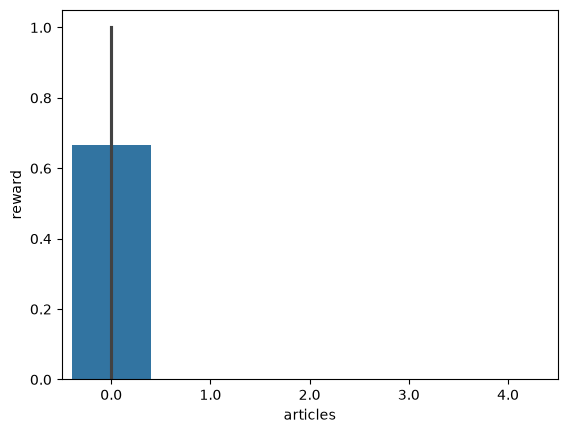

In [8]:
sns.barplot(data=df, x='articles', y='reward')

<Axes: xlabel='articles', ylabel='reward'>

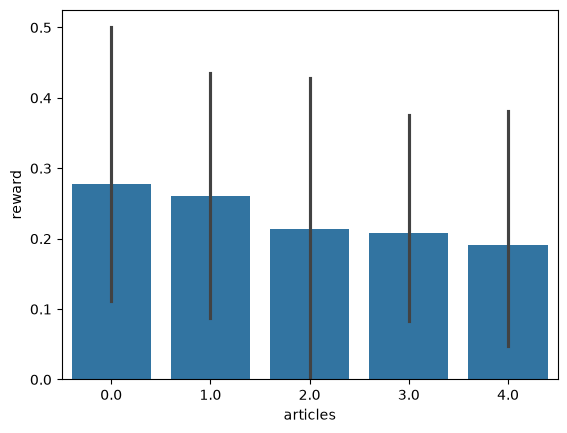

In [ ]:
env_config = {'n_samples':100000}
env = Contextual_Bandit_generator(env_config)
for _ in range(100):
    env.step()
    env.reward(np.random.choice(5))
df = pd.DataFrame(data={'articles':env.state['article'], 'reward':env.state['reward']})
sns.barplot(data=df, x='articles', y='reward')

In [10]:
for a in df['articles'].unique():
    a_count = df['articles'].value_counts(a, 0)
    reward_sum = df.iloc[df['articles']==a]['reward'].sum()
    out = reward_sum/a_count
    print(a, out)

4.0 articles
4.0    19.047619
1.0    17.391304
3.0    16.666667
0.0    22.222222
2.0    28.571429
Name: proportion, dtype: float64
1.0 articles
4.0    28.571429
1.0    26.086957
3.0    25.000000
0.0    33.333333
2.0    42.857143
Name: proportion, dtype: float64
3.0 articles
4.0    23.809524
1.0    21.739130
3.0    20.833333
0.0    27.777778
2.0    35.714286
Name: proportion, dtype: float64
0.0 articles
4.0    0.238095
1.0    0.217391
3.0    0.208333
0.0    0.277778
2.0    0.357143
Name: count, dtype: float64
2.0 articles
4.0    14.285714
1.0    13.043478
3.0    12.500000
0.0    16.666667
2.0    21.428571
Name: proportion, dtype: float64


In [11]:
env.state.keys()

dict_keys(['X', 'article', 'reward'])

In [12]:
env.state['X'][10]

array([ 0.        ,  1.        ,  2.64938041,  0.        , 86.        ])

In [13]:
env.state['article'][10]

np.float64(3.0)

In [14]:
env.state['reward'][10]

np.float64(1.0)

In [15]:
env.state['X'][11]

array([ 1.       ,  0.       ,  2.7316474,  0.       , 61.       ])

In [16]:
env.state['article'][11]

np.float64(2.0)

In [17]:
env.state['reward'][11]

np.float64(0.0)

In [20]:
env.population[0]

array([[ 0.        ,  0.        ,  3.3502568 ,  0.        , 71.        ],
       [ 1.        ,  1.        ,  1.22632911,  0.        , 86.        ],
       [ 0.        ,  1.        ,  2.19731458,  0.        , 69.        ],
       ...,
       [ 1.        ,  1.        ,  6.07763587,  1.        , 63.        ],
       [ 0.        ,  1.        ,  2.69346244,  0.        , 69.        ],
       [ 1.        ,  1.        ,  2.97097428,  0.        , 66.        ]],
      shape=(100000, 5))

In [21]:
env.population[1]

array([2, 4, 0, ..., 2, 0, 2], shape=(100000,))

In [22]:
env.population[1]

array([2, 4, 0, ..., 2, 0, 2], shape=(100000,))

In [23]:
np.unique(env.population[1])

array([0, 1, 2, 3, 4])

In [24]:
df.head()

,articles,reward
0,4.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,1.0
4,3.0,0.0


In [25]:
df.shape

(100, 2)

In [32]:
prob_dict = {'a':[], 'p':[]}
for a in df['articles'].unique():
    r_sum = df.loc[df['articles']==a]['reward'].sum()
    prob = r_sum/df.shape[0]
    prob_dict['a'].append(a)
    prob_dict['p'].append(prob)
dx = pd.DataFrame(data=prob_dict)

In [48]:
pd.concat([dx, pd.DataFrame(data={'a':[5], 'p':[0.06]})])

,a,p
0,4.0,0.04
1,1.0,0.06
2,3.0,0.05
3,0.0,0.05
4,2.0,0.03
0,5.0,0.06


In [49]:
dx

,a,p
0,4.0,0.04
1,1.0,0.06
2,3.0,0.05
3,0.0,0.05
4,2.0,0.03


In [50]:
dx['p'].idxmax()

1

In [51]:
dx['p'].idxmin()

4

In [52]:
e = 0.1
choice = dx.loc[dx['p']>=e]['p'].idxmax()
choice

ValueError: attempt to get argmax of an empty sequence

In [55]:
dx

,a,p
0,4.0,0.04
1,1.0,0.06
2,3.0,0.05
3,0.0,0.05
4,2.0,0.03


In [59]:
e = 0.1
if not dx['p'].ge(e).empty:
    choice = dx['p'].idxmax()
else:
    choice = dx.loc[dx['p']>=e]['p'].idxmax()
choice

1